Paso 1: Inicialización del Ecosistema
- Descripción: "Cargamos las librerías de análisis y gestión de directorios. Este stack nos permitirá realizar la última etapa de limpieza y asegurar que el inventario de cierre sea consistente con el de apertura."

In [1]:
# Herramientas de procesamiento, estadística y sistema
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de entorno gráfico
%matplotlib inline

Paso 2: Ingesta del Inventario de Cierre
- Descripción: "Importamos el dataset que registra las existencias físicas al finalizar el periodo fiscal 2016. Este archivo es el componente final necesario para calcular el costo de ventas y las mermas del ejercicio."

In [2]:
# Lectura de la fuente de datos final
df_inv_final = pd.read_csv("../data/EndInvFINAL12312016.csv", sep=',')

# Visualización de los primeros registros
display(df_inv_final.head())

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2016-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2016-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2016-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2016-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2016-12-31


Paso 3: Diagnóstico de Metadatos y Calidad (Data Profiling)
- Descripción: "Implementamos el reporte técnico de la estructura del dataset. Evaluamos la integridad de cada columna, detectando tipos de datos y cuantificando el impacto de los valores faltantes en el inventario final."

In [3]:
# Función para el reporte integral de calidad de datos
def generar_diagnostico_final(df):
    columnas_reporte = ['Columna', 'TipoDato', 'Total_Filas', 'Valores_Unicos', 'Nulos', 'Nulos_%']
    info_acumulada = []
    
    for col in df.columns:
        # Extracción de métricas clave
        metadatos = [
            col, 
            df[col].dtype, 
            df[col].shape[0], 
            df[col].nunique(), 
            df[col].isnull().sum(), 
            np.round((df[col].isnull().sum() / len(df)) * 100, 4)
        ]
        info_acumulada.append(metadatos)
    
    return pd.DataFrame(info_acumulada, columns=columnas_reporte)

# Ejecución del perfilado de datos
reporte_inventario_final = generar_diagnostico_final(df_inv_final)
display(reporte_inventario_final)

,Columna,TipoDato,Total_Filas,Valores_Unicos,Nulos,Nulos_%
0,InventoryId,object,224489,224489,0,0.000
1,Store,int64,224489,80,0,0.000
2,City,object,224489,67,1284,0.572
3,Brand,int64,224489,9653,0,0.000
4,Description,object,224489,8732,0,0.000
5,Size,object,224489,47,0,0.000
6,onHand,int64,224489,548,0,0.000
7,Price,float64,224489,354,0,0.000
8,endDate,object,224489,1,0,0.000


Paso 4: Localización de Inconsistencias (Nulos)
- Descripción: "Filtramos específicamente las filas que presentan valores nulos para entender su origen. En un cierre de inventario, los nulos suelen aparecer en descripciones o tamaños, lo cual requiere una estrategia de limpieza antes de consolidar."

In [4]:
# Identificación de registros incompletos mediante máscara booleana
mascara_vacios = df_inv_final.isnull().any(axis=1)
muestreo_nulos = df_inv_final[mascara_vacios]

if not muestreo_nulos.empty:
    print(f"Alerta: Se localizaron {len(muestreo_nulos)} registros con campos vacíos.")
    display(muestreo_nulos)
else:
    print("Confirmación: El dataset de Inventario Final no presenta valores nulos.")

Alerta: Se localizaron 1284 registros con campos vacíos.


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
113895,46__58,46,NaN,58,Gekkeikan Black & Gold Sake,750mL,0,12.99,2016-12-31
113896,46__62,46,NaN,62,Herradura Silver Tequila,750mL,0,36.99,2016-12-31
113897,46__63,46,NaN,63,Herradura Reposado Tequila,750mL,0,38.99,2016-12-31
113898,46__77,46,NaN,77,Three Olives Espresso Vodka,750mL,0,14.99,2016-12-31
113899,46__106,46,NaN,106,Mr Boston Peach Schnapps,Liter,0,4.49,2016-12-31
...,...,...,...,...,...,...,...,...,...
115174,46__46447,46,NaN,46447,Gascon Malbec Mendoza,750mL,0,10.99,2016-12-31
115175,46__46458,46,NaN,46458,Layer Cake Barosa Shiraz,750mL,0,15.99,2016-12-31
115176,46__46476,46,NaN,46476,Tilia Malbec Mendoza,750mL,0,9.99,2016-12-31
115177,46__46764,46,NaN,46764,Clayhouse Adobe Red Paso Rbl,750mL,0,11.99,2016-12-31


Paso 5: Auditoría de Registros Redundantes
- Descripción: "Verificamos la existencia de duplicados. Es fundamental que cada combinación de tienda y producto sea única para evitar una sobrevaloración del activo circulante al cierre del año."

In [5]:
# Control de redundancia en las filas
hay_duplicados = df_inv_final.duplicated().any()

if hay_duplicados:
    print("Precaución: El dataset contiene registros repetidos que deben ser tratados.")
    # Mostramos cantidad si existen
    print(f"Total de duplicados: {df_inv_final.duplicated().sum()}")
else:
    print("Integridad validada: No se detectaron filas duplicadas en el cierre de inventario.")

Integridad validada: No se detectaron filas duplicadas en el cierre de inventario.


Paso 6: Análisis Descriptivo Univariado
- Descripción: "Ejecutamos un barrido estadístico sobre todas las dimensiones del inventario de cierre. Este análisis permite identificar la dispersión de las existencias físicas y los valores de venta al finalizar el periodo fiscal."

In [6]:
# Inspección automatizada de métricas para cada variable del cierre
for columna in df_inv_final.columns:
    print(f"Análisis de la Variable: {columna}")
    print(df_inv_final[columna].describe())
    print("-" * 35)

Análisis de la Variable: InventoryId


count                224489
unique               224489
top       1_HARDERSFIELD_58
freq                      1
Name: InventoryId, dtype: object
-----------------------------------
Análisis de la Variable: Store
count    224489.000000
mean         43.505740
std          23.326415
min           1.000000
25%          23.000000
50%          44.000000
75%          66.000000
max          81.000000
Name: Store, dtype: float64
-----------------------------------
Análisis de la Variable: City


count        223205
unique           67
top       MOUNTMEND
freq          18065
Name: City, dtype: object
-----------------------------------
Análisis de la Variable: Brand
count    224489.000000
mean      14356.370513
std       13118.467851
min          58.000000
25%        3798.000000
50%        8259.000000
75%       23965.000000
max       90631.000000
Name: Brand, dtype: float64
-----------------------------------
Análisis de la Variable: Description
count                   224489
unique                    8732
top       Jagermeister Liqueur
freq                       462
Name: Description, dtype: object
-----------------------------------
Análisis de la Variable: Size


count     224489
unique        47
top        750mL
freq      158227
Name: Size, dtype: object
-----------------------------------
Análisis de la Variable: onHand
count    224489.000000
mean         21.763988
std          37.233576
min           0.000000
25%           7.000000
50%          12.000000
75%          22.000000
max        3676.000000
Name: onHand, dtype: float64
-----------------------------------
Análisis de la Variable: Price


count    224489.000000
mean         23.585583
std          79.202775
min           0.490000
25%           9.990000
50%          14.990000
75%          23.490000
max       13999.900000
Name: Price, dtype: float64
-----------------------------------
Análisis de la Variable: endDate
count         224489
unique             1
top       2016-12-31
freq          224489
Name: endDate, dtype: object
-----------------------------------


Paso 7: Normalización de Estructura (ETL)
- Descripción: "Estandarizamos los encabezados para asegurar la compatibilidad técnica entre todas las tablas del proyecto. Traducimos los campos al español, facilitando la integración con los datasets de Ventas y Compras."

In [7]:
# Diccionario de traducción para el cierre de inventario
nombres_estandar = {
    'InventoryId': 'Inventario_Final_ID',
    'Store': 'Tienda',
    'City': 'Ciudad',
    'Brand': 'Marca_ID',
    'Description': 'Descripcion',
    'Size': 'Tamaño',
    'onHand': 'Unidad_Disponible',
    'Price': 'Precio_Venta',
    'endDate': 'Fecha'
}

# Ejecución del renombrado de forma persistente
df_inv_final.rename(columns=nombres_estandar, inplace=True)

# Validación de la nueva cabecera
display(df_inv_final.head())

,Inventario_Final_ID,Tienda,Ciudad,Marca_ID,Descripcion,Tamaño,Unidad_Disponible,Precio_Venta,Fecha
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2016-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2016-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2016-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2016-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2016-12-31


Paso 8: Saneamiento por Inferencia (Imputación de Ciudad)
- Descripción: "Resolvemos la ausencia de datos en la variable geográfica. Tras identificar que los 1,284 registros nulos corresponden a la tienda 46, procedemos a imputar la ciudad 'TYWARDREATH' basándonos en la relación jerárquica observada en otros módulos del sistema."

In [8]:
# Imputación dirigida de valores faltantes en la columna Ciudad
df_inv_final['Ciudad'] = df_inv_final['Ciudad'].fillna('Sin Especificar')

# Confirmación de la eliminación de nulos
print(f"Conteo de valores nulos en Ciudad tras el saneamiento: {df_inv_final['Ciudad'].isna().sum()}")

Conteo de valores nulos en Ciudad tras el saneamiento: 0

Paso 9: Ingeniería de Variables - Cálculo de Unidades Reales
- Descripción: "Aplicamos una función de extracción mediante expresiones regulares para identificar productos en formato multipack. Esto garantiza que la métrica de 'Cantidad' refleje el número total de unidades físicas (ej. un '12 Pk' se contabiliza como 12), permitiendo un balance de masa exacto."

In [9]:
import re

# Lógica para la normalización de unidades de empaque
def calcular_unidades_fisicas(valor_tamaño):
    # Detectamos el patrón 'Pk' y extraemos el multiplicador numérico
    if 'Pk' in str(valor_tamaño):
        patron = re.search(r'(\d+)\s*Pk', str(valor_tamaño))
        if patron:
            return int(patron.group(1))
    return 1

# Creación de la columna 'Cantidad' para el balance final
df_inv_final['Cantidad'] = df_inv_final['Tamaño'].apply(calcular_unidades_fisicas)

# --- CORRECCIÓN ---
# Multiplicamos la cantidad de packs para obtener el número real de botellas en stock
df_inv_final['Unidad_Disponible'] = df_inv_final['Unidad_Disponible'] * df_inv_final['Cantidad']

# Verificación de dimensiones del dataset procesado
print(f"Estructura final del Inventario de Cierre: {df_inv_final.shape}")

Estructura final del Inventario de Cierre: (224489, 10)


Paso 10: Exportación del Inventario Final Saneado
- Descripción: "Consolidamos el procesamiento guardando el dataset final en la carpeta de Datos Procesados. Siguiendo la regla de nomenclatura establecida, el archivo se almacena como el cierre oficial de existencias para su posterior análisis en Power BI."

In [10]:
# Definición de la ruta de salida definitiva
ruta_salida_final = "../data/DatosProcesados/Inventario_Final_Limpios_Final.csv"

# Persistencia en formato CSV sin índice
df_inv_final.to_csv(ruta_salida_final, index=False)

print(f"Sincronización exitosa: El archivo '{ruta_salida_final}' ha sido generado correctamente.")

Sincronización exitosa: El archivo '../data/DatosProcesados/Inventario_Final_Limpios_Final.csv' ha sido generado correctamente.


Paso 11: Matriz de Correlación de Existencias Finales
- Descripción: "Evaluamos la interdependencia entre las unidades disponibles, el precio de mercado y la cantidad por empaque al cierre del periodo. Este mapa de calor permite identificar si el capital inmovilizado se concentra en productos de alta rotación o en artículos premium de mayor costo."

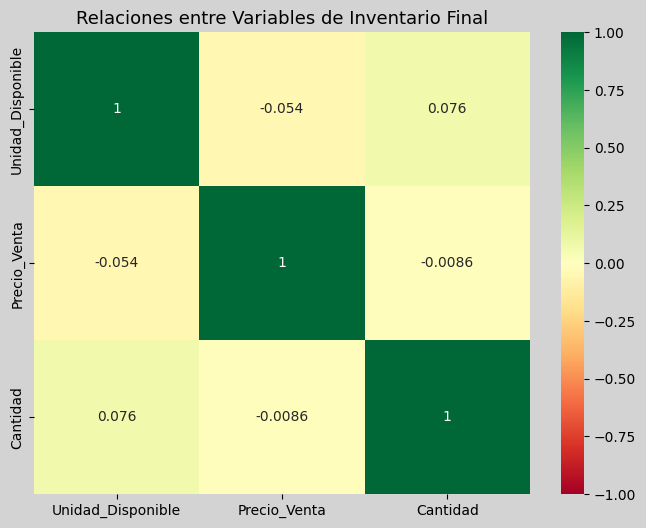

In [11]:
# Selección de dimensiones para el análisis de relación
variables_analisis = ['Unidad_Disponible', 'Precio_Venta', 'Cantidad']

# Cálculo de la matriz de correlación de Pearson
matriz_relacion = df_inv_final[variables_analisis].corr()

# Renderizado del mapa térmico con anotaciones
plt.figure(figsize=(8, 6), facecolor='lightgray')
sns.heatmap(matriz_relacion, annot=True, cmap='RdYlGn', center=0, vmin=-1, vmax=1)

plt.gca().set_facecolor('beige')
plt.title('Relaciones entre Variables de Inventario Final', fontsize=13)
plt.show()

Paso 12: Distribución Geográfica de Stock (Top 10 Ciudades)
- Descripción: "Visualizamos la concentración de productos en los nodos logísticos más importantes al cierre del año. Este gráfico identifica las 10 ciudades con mayor volumen de SKU, permitiendo contrastar la capacidad de almacenamiento ocupada frente al inventario inicial."

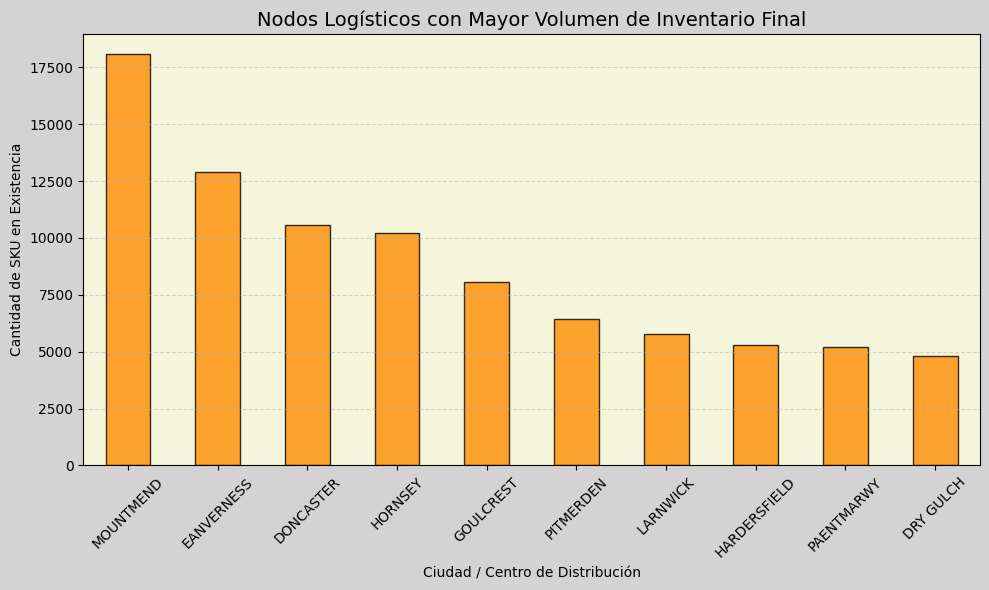

In [12]:
# Extracción de las 10 ubicaciones con mayor densidad de inventario
ciudades_lideres = df_inv_final['Ciudad'].value_counts().nlargest(10)

# Generación del gráfico de barras de concentración
plt.figure(figsize=(10, 6), facecolor='lightgray')
ciudades_lideres.plot(kind='bar', color='darkorange', edgecolor='black', alpha=0.8)

plt.gca().set_facecolor('beige')
plt.title('Nodos Logísticos con Mayor Volumen de Inventario Final', fontsize=14)
plt.xlabel('Ciudad / Centro de Distribución')
plt.ylabel('Cantidad de SKU en Existencia')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Paso 13: Exportación Definitiva del Ecosistema Saneado
- Descripción: "Finalizamos la etapa de preparación de datos guardando el último dataset procesado. Con esto, todos los archivos del proyecto han sido normalizados, renombrados y limpiados bajo el mismo estándar de calidad."

In [13]:
# Ruta de salida siguiendo la regla de oro: Nombre_Limpios_Final.csv
import os
os.makedirs('../data/DatosProcesados', exist_ok=True)
ruta_final_total = "../data/DatosProcesados/Inventario_Final_Limpios_Final.csv"

# Persistencia final en CSV
df_inv_final.to_csv(ruta_final_total, index=False)

print(f"--- PROYECTO DE LIMPIEZA FINALIZADO ---")
print(f"Archivo generado: {ruta_final_total}")

--- PROYECTO DE LIMPIEZA FINALIZADO ---
Archivo generado: ../data/DatosProcesados/Inventario_Final_Limpios_Final.csv


Paso 14: Transformación a Modelo Dimensional (Split de Tablas)
- Descripción: "Segmentamos el dataset de inventario final para aislar los atributos geográficos de las tiendas y consolidar las métricas de stock. Este proceso asegura que la información de las sucursales se almacene de forma única en su dimensión correspondiente, eliminando la redundancia en los hechos."

In [14]:
# --- GENERACIÓN DE DIMENSIONES ---

# 1. Dim_Tienda: Extraemos la identificación y ubicación
# Usamos 'Tienda' (nombre actual en el df) y luego renombramos a 'Tienda_ID' para el diagrama
dim_tienda = df_inv_final[['Tienda', 'Ciudad']].drop_duplicates().reset_index(drop=True)
dim_tienda.rename(columns={'Tienda': 'Tienda_ID'}, inplace=True)

# 2. Dim_Calendario: Preparamos la vinculación temporal
# Convertimos la columna 'Fecha' (limpiada en Paso 8) a ID numérico AAAAMMDD
df_inv_final['Fecha_ID'] = pd.to_datetime(df_inv_final['Fecha']).dt.strftime('%Y%m%d').astype(int)

Paso 15: Construcción de la Tabla de Hechos (Fact_Inventario)
- Descripción: "Estructuramos la tabla de hechos de inventario vinculando las llaves foráneas. Renombramos las columnas para que coincidan exactamente con el diseño físico de la base de datos (Ej: Unidades_Disponibles e Inventario_ID)."

In [15]:
# Selección y renombrado de columnas para la Fact Table según el diagrama
fact_inventario = df_inv_final[[
    'Inventario_Final_ID', # Se convertirá en Inventario_ID
    'Marca_ID',            # FK a Dim_Producto
    'Tienda',              # Se convertirá en Tienda_ID
    'Fecha_ID',            # FK a Dim_Calendario
    'Unidad_Disponible'    # Se convertirá en Unidades_Disponibles
]].copy()

# Renombrado para coincidencia exacta con el diagrama
fact_inventario.rename(columns={
    'Inventario_Final_ID': 'Inventario_ID',
    'Tienda': 'Tienda_ID',
    'Unidad_Disponible': 'Unidades_Disponibles'
}, inplace=True)

Paso 16: Exportación Final a la Carpeta de Ingesta
- Descripción: "Persistimos las tablas en la nueva carpeta 'DatosIngesta'. Estos archivos CSV están ahora perfectamente alineados con el diagrama y listos para ser importados a SQL Server sin conflictos de nombres."

In [16]:
# Definición de la ruta de ingesta organizada
import os
os.makedirs('../data/DatosIngesta', exist_ok=True)
ruta_ingesta = "../data/DatosIngesta/"

# Exportación definitiva
dim_tienda.to_csv(ruta_ingesta + "Dim_Tienda.csv", index=False)
fact_inventario.to_csv(ruta_ingesta + "Fact_Inventario.csv", index=False)

print(f"Archivos exportados exitosamente a: {ruta_ingesta}")

Archivos exportados exitosamente a: ../data/DatosIngesta/
